In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

pd.set_option("display.max_columns", None)

In [7]:
import pandas as pd

df = pd.read_csv(
    "../data/processed/cleaned_student_data.csv"
)

df.head()

,Performance,Gender,Caste,coaching,time,Class_ten_education,twelve_education,medium,Class_ X_Percentage,Class_XII_Percentage,Father_occupation,Mother_occupation
0,Excellent,male,General,NO,ONE,SEBA,AHSEC,ENGLISH,Excellent,Excellent,DOCTOR,OTHERS
1,Excellent,male,OBC,WA,TWO,SEBA,AHSEC,OTHERS,Excellent,Excellent,SCHOOL_TEACHER,HOUSE_WIFE
2,Excellent,male,OBC,OA,TWO,OTHERS,CBSE,ENGLISH,Excellent,Excellent,BUSINESS,HOUSE_WIFE
3,Excellent,male,General,WA,ONE,SEBA,AHSEC,OTHERS,Excellent,Excellent,SCHOOL_TEACHER,SCHOOL_TEACHER
4,Excellent,male,General,OA,TWO,SEBA,CBSE,ENGLISH,Excellent,Excellent,COLLEGE_TEACHER,HOUSE_WIFE


In [25]:
df.shape

(622, 12)

In [26]:
df.info

<bound method DataFrame.info of     Performance  Gender    Caste coaching   time Class_ten_education  \
0     Excellent    male  General       NO    ONE                SEBA   
1     Excellent    male      OBC       WA    TWO                SEBA   
2     Excellent    male      OBC       OA    TWO              OTHERS   
3     Excellent    male  General       WA    ONE                SEBA   
4     Excellent    male  General       OA    TWO                SEBA   
..          ...     ...      ...      ...    ...                 ...   
617     Average  female       ST       WA    TWO                SEBA   
618     Average  female       ST       WA    ONE                SEBA   
619     Average    male       ST       WA  THREE                SEBA   
620     Average    male       ST       WA    TWO                SEBA   
621     Average  female       ST       NO    ONE                SEBA   

    twelve_education   medium Class_ X_Percentage Class_XII_Percentage  \
0              AHSEC  ENGLISH

In [27]:
df.describe(include="all")

,Performance,Gender,Caste,coaching,time,Class_ten_education,twelve_education,medium,Class_ X_Percentage,Class_XII_Percentage,Father_occupation,Mother_occupation
count,622,622,622,622,622,622,622,622,622,622,622,622
unique,4,2,4,3,6,3,3,3,4,4,8,9
top,Good,male,General,WA,TWO,SEBA,AHSEC,ENGLISH,Excellent,Excellent,OTHERS,HOUSE_WIFE
freq,194,334,299,413,339,375,348,495,469,362,243,407


In [28]:
df.isnull().sum()

Performance             0
Gender                  0
Caste                   0
coaching                0
time                    0
Class_ten_education     0
twelve_education        0
medium                  0
Class_ X_Percentage     0
Class_XII_Percentage    0
Father_occupation       0
Mother_occupation       0
dtype: int64

In [29]:
df.nunique()

Performance             4
Gender                  2
Caste                   4
coaching                3
time                    6
Class_ten_education     3
twelve_education        3
medium                  3
Class_ X_Percentage     4
Class_XII_Percentage    4
Father_occupation       8
Mother_occupation       9
dtype: int64

In [30]:
df["Performance"].value_counts(normalize=True) * 100

Performance
Good         31.189711
Vg           28.617363
Average      24.437299
Excellent    15.755627
Name: proportion, dtype: float64

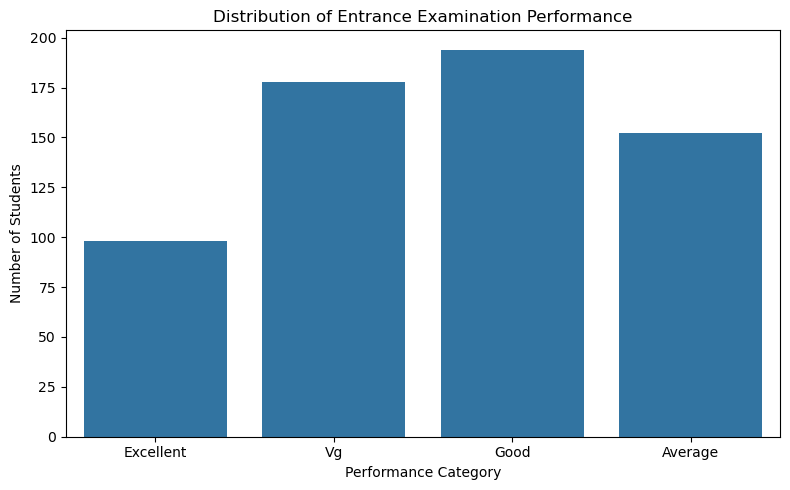

In [8]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Performance"
)

plt.title("Distribution of Entrance Examination Performance")
plt.xlabel("Performance Category")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

1)Is participation in coaching associated with entrance-examination performance?

In [9]:
q1_counts=pd.crosstab(
    df["coaching"],
    df["Performance"]
)
q1_counts

Performance,Average,Excellent,Good,Vg
coaching,,,,
NO,40,20,47,37
OA,9,23,19,14
WA,103,55,128,127


In [10]:
q1_percent = pd.crosstab(
    df["coaching"],
    df["Performance"],
    normalize="index"
) * 100

q1_percent.round(2)

Performance,Average,Excellent,Good,Vg
coaching,,,,
NO,27.78,13.89,32.64,25.69
OA,13.85,35.38,29.23,21.54
WA,24.94,13.32,30.99,30.75


visualize it

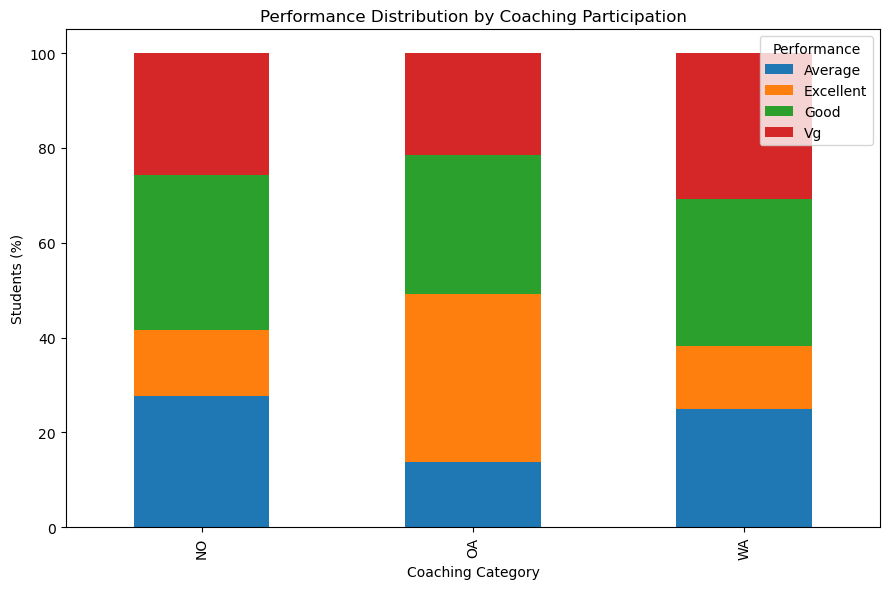

In [13]:
q1_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 6)
)

plt.title(
    "Performance Distribution by Coaching Participation"
)

plt.xlabel("Coaching Category")
plt.ylabel("Students (%)")
plt.legend(title="Performance")

plt.tight_layout()
plt.show()


In [14]:
fig, ax = plt.subplots(figsize=(9, 6))
q1_percent.plot(kind="bar", stacked=True, ax=ax)

ax.set_title("Performance Distribution by Coaching Participation")
ax.set_xlabel("Coaching Category")
ax.set_ylabel("Students (%)")
ax.legend(title="Performance")

plt.tight_layout()
fig.savefig("../outputs/figures/q1_coaching_performance.png", dpi=300, bbox_inches="tight")
plt.close(fig)

statistical test


In [35]:
chi2, p_value, degrees_of_freedom, expected = chi2_contingency(
    q1_counts
)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", degrees_of_freedom)

Chi-square statistic: 23.86328671951955
p-value: 0.0005533754217145697
Degrees of freedom: 6


In [36]:
alpha = 0.05

if p_value < alpha:
    print(
        "There is statistical evidence of an association "
        "between coaching participation and performance."
    )
else:
    print(
        "There is not sufficient statistical evidence of an "
        "association between coaching participation and performance."
    )

There is statistical evidence of an association between coaching participation and performance.


2)How is Class XII academic performance associated with entrance-examination performance?

In [15]:
q2_counts = pd.crosstab(
    df["Class_XII_Percentage"],
    df["Performance"]
)

q2_counts

Performance,Average,Excellent,Good,Vg
Class_XII_Percentage,,,,
Average,6,2,3,1
Excellent,56,75,110,121
Good,36,9,19,10
Vg,54,12,62,46


In [16]:
q2_percent = pd.crosstab(
    df["Class_XII_Percentage"],
    df["Performance"],
    normalize="index"
) * 100

q2_percent.round(2)

Performance,Average,Excellent,Good,Vg
Class_XII_Percentage,,,,
Average,50.00,16.67,25.00,8.33
Excellent,15.47,20.72,30.39,33.43
Good,48.65,12.16,25.68,13.51
Vg,31.03,6.90,35.63,26.44


visualize

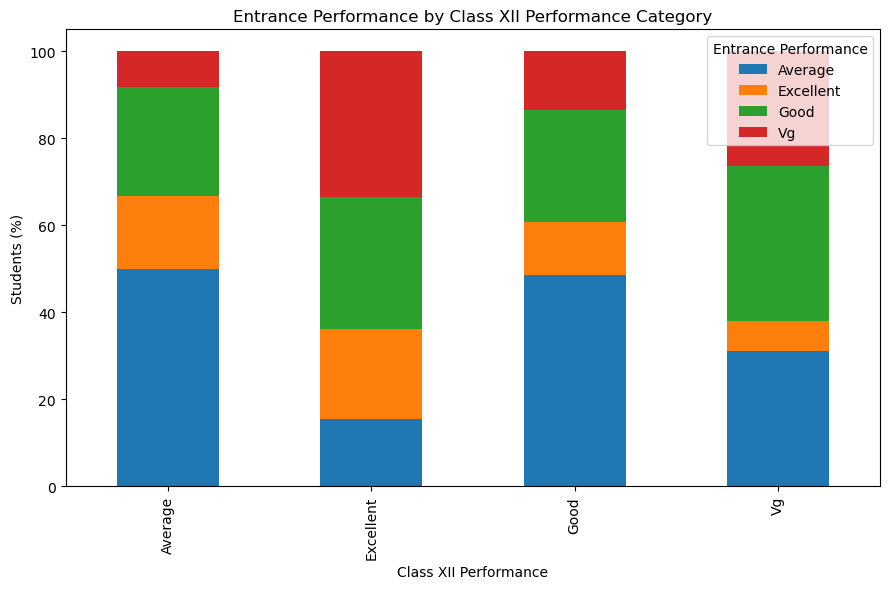

In [17]:
q2_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 6)
)

plt.title(
    "Entrance Performance by Class XII Performance Category"
)

plt.xlabel("Class XII Performance")
plt.ylabel("Students (%)")
plt.legend(title="Entrance Performance")

plt.tight_layout()
plt.show()

In [18]:
fig, ax = plt.subplots(figsize=(9, 6))
q2_percent.plot(kind="bar", stacked=True, ax=ax)

ax.set_title("Entrance Performance by Class XII Performance Category")
ax.set_xlabel("Class XII Performance")
ax.set_ylabel("Students (%)")
ax.legend(title="Entrance Performance")

plt.tight_layout()
fig.savefig("../outputs/figures/q2_class12_performance.png", dpi=300, bbox_inches="tight")
plt.close(fig)

statistical test

In [43]:
chi2, p_value, degrees_of_freedom, expected = chi2_contingency(
    q2_counts
)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", degrees_of_freedom)

Chi-square statistic: 63.792217357029855
p-value: 2.476645834938412e-10
Degrees of freedom: 9


In [44]:
if p_value < 0.05:
    print(
        "There is statistical evidence of an association "
        "between Class XII performance and entrance performance."
    )
else:
    print(
        "There is not sufficient statistical evidence of an "
        "association between Class XII performance and entrance performance."
    )

There is statistical evidence of an association between Class XII performance and entrance performance.


3)Does reported coaching duration show different performance patterns?

In [45]:
df["time"].value_counts()

time
TWO      339
ONE      185
THREE     85
FOUR      11
FIVE       1
SEVEN      1
Name: count, dtype: int64

In [19]:
q3_counts = pd.crosstab(
    df["time"],
    df["Performance"]
)

q3_counts

Performance,Average,Excellent,Good,Vg
time,,,,
FIVE,0,0,1,0
FOUR,2,0,5,4
ONE,45,27,58,55
SEVEN,0,0,1,0
THREE,21,5,31,28
TWO,84,66,98,91


In [20]:
q3_percent = pd.crosstab(
    df["time"],
    df["Performance"],
    normalize="index"
) * 100

q3_percent.round(2)

Performance,Average,Excellent,Good,Vg
time,,,,
FIVE,0.00,0.00,100.00,0.00
FOUR,18.18,0.00,45.45,36.36
ONE,24.32,14.59,31.35,29.73
SEVEN,0.00,0.00,100.00,0.00
THREE,24.71,5.88,36.47,32.94
TWO,24.78,19.47,28.91,26.84


visualize

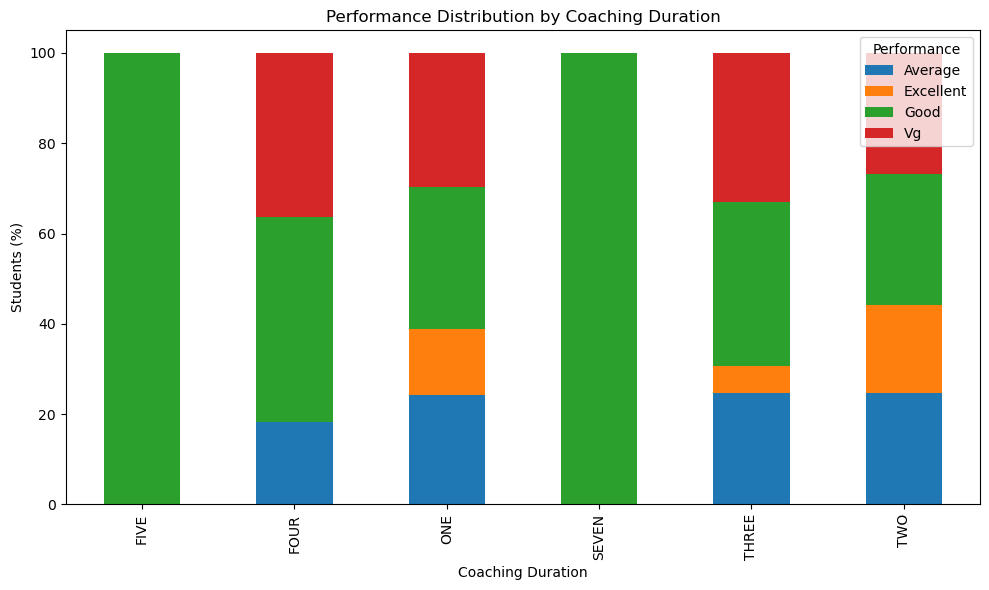

In [21]:
q3_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title(
    "Performance Distribution by Coaching Duration"
)

plt.xlabel("Coaching Duration")
plt.ylabel("Students (%)")
plt.legend(title="Performance")

plt.tight_layout()
plt.show()

In [22]:
fig, ax = plt.subplots(figsize=(9, 6))
q2_percent.plot(kind="bar", stacked=True, ax=ax)

ax.set_title("Entrance Performance by Class XII Performance Category")
ax.set_xlabel("Class XII Performance")
ax.set_ylabel("Students (%)")
ax.legend(title="Entrance Performance")

plt.tight_layout()
fig.savefig("../outputs/figures/q3_coaching_duration.png", dpi=300, bbox_inches="tight")
plt.close(fig)

statistical test

In [49]:
chi2, p_value, degrees_of_freedom, expected = chi2_contingency(
    q3_counts
)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", degrees_of_freedom)

Chi-square statistic: 18.00893002209537
p-value: 0.26219637332932655
Degrees of freedom: 15
